In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("../output/sampler10.csv")

In [3]:
df["S"] += -170

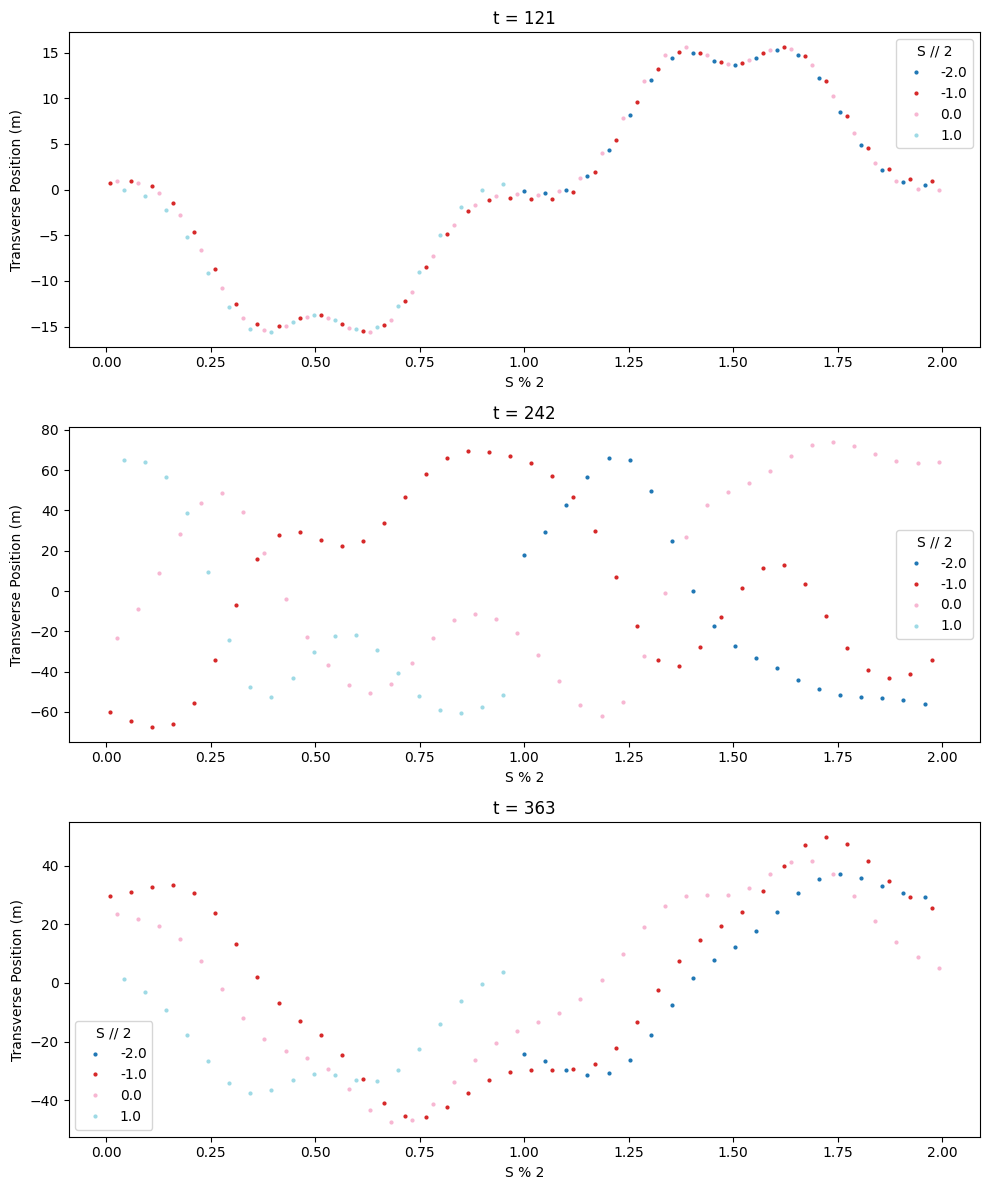

In [4]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# Get unique t values
t_values = df['t'].unique()

# Create a subplot for each t
fig, axes = plt.subplots(len(t_values), 1, figsize=(10, 4*len(t_values)))

# Handle case where there's only one t value
if len(t_values) == 1:
    axes = [axes]

for ax, t in zip(axes, t_values):
    # Filter data for this t
    t_df = df[df['t'] == t]
    
    # Group by S // 2
    groups = t_df.groupby(t_df["S"] // 2)
    colors = cm.tab20(np.linspace(0, 1, len(groups)))
    
    for (name, group), color in zip(groups, colors):
        ax.plot((group["S"] % 2), group["x"]*1000, "o", color=color,
                label=str(name), markersize=2)

    
    ax.set_xlabel("S % 2")
    ax.set_ylabel("Transverse Position (m)")
    ax.set_title(f"t = {t}")
    ax.legend(title="S // 2")

plt.tight_layout()
plt.show()